# Capstone: CTR / Engagement Opportunity Scoring (Lane 4)

Question: Which visible pages get fewer clicks than expected for their position, and can a model rank them better than my rule-based baseline?

Decision supported:Which pages should get a metadata or content review first.

Data: FlyRank ML Internship dataset (engagement_fix lane, pseudonymized example cut).

In [4]:
!pip -q install duckdb huggingface_hub pandas scikit-learn matplotlib
!git clone https://github.com/unatisaini/flyrank-internship-ml.git
%cd flyrank-internship-ml

Cloning into 'flyrank-internship-ml'...
remote: Enumerating objects: 177, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 177 (delta 80), reused 94 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (177/177), 1.87 MiB | 12.36 MiB/s, done.
Resolving deltas: 100% (80/80), done.
/content/flyrank-internship-ml


In [6]:
from huggingface_hub import login, list_repo_files
login()
files = list_repo_files("FlyRank/internship-lanes", repo_type="dataset")
for f in files:
    print(f)

.gitattributes
README.md
default_lanes/ai_opportunity.parquet
default_lanes/decline_recovery.parquet
default_lanes/engagement_fix.parquet
default_lanes/ranking_lifecycle.parquet
restricted_lanes/cannibalization_restricted.parquet
restricted_lanes/semantic_clustering_restricted.parquet


In [11]:
from getpass import getpass
from huggingface_hub import login
login(token=getpass("Paste HF read token: "))

Paste HF read token: ··········


In [12]:
from huggingface_hub import hf_hub_download
import pandas as pd

path = hf_hub_download(
    repo_id="FlyRank/internship-lanes",
    filename="default_lanes/engagement_fix.parquet",
    repo_type="dataset",
)
df = pd.read_parquet(path)

print(df.shape)
print(df.dtypes)
df.head()

default_lanes/engagement_fix.parquet: reconstructing file:   0%|          |  0.00B /  760kB            

default_lanes/engagement_fix.parquet: downloading bytes:           |  0.00B            

(33202, 31)
client_hash_id           object
content_hash_id          object
content_type             object
main_intent              object
age_tier                 object
freshness_tier           object
word_count_tier          object
char_count_tier          object
client_has_gsc             bool
client_has_ga4             bool
impressions_30d           int64
clicks_30d                int64
pageviews_30d             int64
sessions_30d              int64
users_30d                 int64
engaged_sessions_30d      int64
ai_sessions_30d           int64
scroll_events_30d         int64
ctr_30d                 float64
avg_position_30d        float64
engagement_rate_30d     float64
scroll_rate_30d         float64
ai_traffic_pct_30d      float64
impression_tier          object
position_tier            object
health_score              int64
needs_indexing             bool
is_quick_win               bool
needs_ctr_fix              bool
needs_engagement_fix       bool
ai_opportunity             b

,client_hash_id,content_hash_id,content_type,main_intent,age_tier,freshness_tier,word_count_tier,char_count_tier,client_has_gsc,client_has_ga4,...,scroll_rate_30d,ai_traffic_pct_30d,impression_tier,position_tier,health_score,needs_indexing,is_quick_win,needs_ctr_fix,needs_engagement_fix,ai_opportunity
0,client_f456856b7023ca82,content_24cff3eaee1df6bf,keyword article,informational,365+,31-90,None,None,True,True,...,8.33,0.00,moderate,striking,40,False,True,False,True,False
1,client_f456856b7023ca82,content_ee97ed5ba8d00f73,keyword article,informational,365+,31-90,None,None,True,True,...,22.92,0.00,good,page_1,60,False,False,True,True,True
2,client_f456856b7023ca82,content_de7992421a09be04,feedly article,unknown,181-365,31-90,1000-2000,<8000,True,True,...,4.55,0.00,low,top_3,55,False,False,False,True,False
3,client_f456856b7023ca82,content_79d5e5320dc338e8,feedly article,unknown,181-365,31-90,<1000,<8000,True,True,...,29.63,0.00,moderate,striking,55,False,False,False,True,True
4,client_f456856b7023ca82,content_27b5618b1038fc54,feedly article,unknown,181-365,31-90,1000-2000,<8000,True,True,...,23.08,8.33,moderate,page_1,60,False,False,False,True,False


In [13]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("COLUMNS:")
for i, c in enumerate(df.columns, 1):
    print(i, c, "|", df[c].dtype, "| nulls:", df[c].isna().sum())

print("\nDUPLICATE ROWS:", df.duplicated().sum())
df.describe().T

COLUMNS:
1 client_hash_id | object | nulls: 0
2 content_hash_id | object | nulls: 0
3 content_type | object | nulls: 0
4 main_intent | object | nulls: 0
5 age_tier | object | nulls: 0
6 freshness_tier | object | nulls: 0
7 word_count_tier | object | nulls: 5680
8 char_count_tier | object | nulls: 5680
9 client_has_gsc | bool | nulls: 0
10 client_has_ga4 | bool | nulls: 0
11 impressions_30d | int64 | nulls: 0
12 clicks_30d | int64 | nulls: 0
13 pageviews_30d | int64 | nulls: 0
14 sessions_30d | int64 | nulls: 0
15 users_30d | int64 | nulls: 0
16 engaged_sessions_30d | int64 | nulls: 0
17 ai_sessions_30d | int64 | nulls: 0
18 scroll_events_30d | int64 | nulls: 0
19 ctr_30d | float64 | nulls: 358
20 avg_position_30d | float64 | nulls: 358
21 engagement_rate_30d | float64 | nulls: 0
22 scroll_rate_30d | float64 | nulls: 0
23 ai_traffic_pct_30d | float64 | nulls: 0
24 impression_tier | object | nulls: 0
25 position_tier | object | nulls: 0
26 health_score | int64 | nulls: 0
27 needs_indexin

,count,mean,std,min,25%,50%,75%,max
impressions_30d,33202.0,4408.468526,11086.942934,0.0,417.00,1607.00,4285.00,576250.00
clicks_30d,33202.0,22.846666,725.729658,0.0,1.00,7.00,17.00,97954.00
pageviews_30d,33202.0,79.752786,3097.965857,8.0,19.00,26.00,54.00,396910.00
sessions_30d,33202.0,44.879917,1008.607189,10.0,15.00,20.00,36.00,128005.00
users_30d,33202.0,43.292392,1018.730654,3.0,14.00,19.00,35.00,129807.00
engaged_sessions_30d,33202.0,1.083368,4.443106,0.0,0.00,0.00,1.00,387.00
ai_sessions_30d,33202.0,0.138516,4.005327,0.0,0.00,0.00,0.00,507.00
scroll_events_30d,33202.0,3.514035,125.272689,0.0,0.00,1.00,4.00,16103.00
ctr_30d,32844.0,0.452820,0.699331,0.0,0.08,0.31,0.63,53.22
avg_position_30d,32844.0,13.074991,11.438738,0.0,5.80,9.20,18.40,122.60


In [14]:
print(list(df.columns[19:]))
print()
print(df.select_dtypes("bool").mean().round(3))
print()
df[list(df.columns[19:])].head(8)

['avg_position_30d', 'engagement_rate_30d', 'scroll_rate_30d', 'ai_traffic_pct_30d', 'impression_tier', 'position_tier', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'ai_opportunity']

client_has_gsc          1.000
client_has_ga4          1.000
needs_indexing          0.011
is_quick_win            0.190
needs_ctr_fix           0.407
needs_engagement_fix    1.000
ai_opportunity          0.470
dtype: float64



,avg_position_30d,engagement_rate_30d,scroll_rate_30d,ai_traffic_pct_30d,impression_tier,position_tier,health_score,needs_indexing,is_quick_win,needs_ctr_fix,needs_engagement_fix,ai_opportunity
0,16.8,10.0,8.33,0.00,moderate,striking,40,False,True,False,True,False
1,4.2,0.0,22.92,0.00,good,page_1,60,False,False,True,True,True
2,2.7,0.0,4.55,0.00,low,top_3,55,False,False,False,True,False
3,10.3,0.0,29.63,0.00,moderate,striking,55,False,False,False,True,True
4,6.5,0.0,23.08,8.33,moderate,page_1,60,False,False,False,True,False
5,9.7,10.0,27.27,0.00,moderate,page_1,60,False,False,False,True,False
6,3.8,0.0,26.32,0.00,moderate,page_1,65,False,False,False,True,True
7,14.4,0.0,0.00,0.00,good,striking,50,False,True,False,True,False


In [15]:
print("Clients:", df.client_hash_id.nunique())
print(df.groupby("client_hash_id").size().describe().round(1))

print("\nBy position_tier:")
print(df.groupby("position_tier").agg(
    rows=("needs_ctr_fix", "size"),
    fix_rate=("needs_ctr_fix", "mean"),
    med_ctr=("ctr_30d", "median")).round(3))

print("\nBy impression_tier:")
print(df.groupby("impression_tier").agg(
    rows=("needs_ctr_fix", "size"),
    fix_rate=("needs_ctr_fix", "mean"),
    med_impr=("impressions_30d", "median")).round(3))

print("\nContent types:")
print(df.content_type.value_counts().head(8))

Clients: 44
count      44.0
mean      754.6
std      2014.0
min         1.0
25%         8.5
50%        57.5
75%       437.2
max      9400.0
dtype: float64

By position_tier:
                rows  fix_rate  med_ctr
position_tier                          
deep             359     0.000     0.00
no_data          358     0.000      NaN
page_1         13660     0.970     0.44
page_3_5        7013     0.000     0.21
striking        7725     0.000     0.40
top_3           4087     0.064     0.00

By impression_tier:
                  rows  fix_rate  med_impr
impression_tier                           
excellent         3433     0.820   16983.0
good             16771     0.548    2771.0
low               4766     0.000       3.0
moderate          7874     0.191     506.0
none               358     0.000       0.0

Content types:
content_type
keyword article       29267
feedly article         3933
comparison article        2
Name: count, dtype: int64


In [16]:
import numpy as np

d = df.dropna(subset=["ctr_30d", "avg_position_30d"]).copy()
d["ctr_calc"] = d.clicks_30d / d.impressions_30d.replace(0, np.nan) * 100
print("CTR unit check:", (d.ctr_30d - d.ctr_calc).abs().describe().round(3).to_dict())

MIN_IMPR = 100
a = d[d.impressions_30d >= MIN_IMPR].copy()
print("all / with CTR / visible:", len(df), len(d), len(a))
print("clients:", a.client_hash_id.nunique())
print("largest client share:", round(a.client_hash_id.value_counts(normalize=True).iloc[0], 3))

bins = [0, 1, 2, 3, 5, 7, 10, 15, 20, 30, 200]
a["pos_band"] = pd.cut(a.avg_position_30d, bins, include_lowest=True)
a["exp_ctr"] = a.groupby("pos_band", observed=True).ctr_30d.transform("median")
print(a.groupby("pos_band", observed=True).agg(rows=("ctr_30d", "size"), exp_ctr=("exp_ctr", "first")).round(2))

a = a[a.exp_ctr > 0].copy()
a["ctr_ratio"] = a.ctr_30d / a.exp_ctr
a["underperf"] = (a.ctr_ratio < 0.5).astype(int)
print("underperformer rate:", round(a.underperf.mean(), 3))

CTR unit check: {'count': 32844.0, 'mean': 0.002, 'std': 0.002, 'min': 0.0, '25%': 0.0, '50%': 0.002, '75%': 0.003, 'max': 0.005}
all / with CTR / visible: 33202 32844 28078
clients: 38
largest client share: 0.322
               rows  exp_ctr
pos_band                    
(-0.001, 1.0]     3     3.55
(1.0, 2.0]       39     0.86
(2.0, 3.0]      256     0.72
(3.0, 5.0]     2347     0.60
(5.0, 7.0]     4950     0.47
(7.0, 10.0]    6291     0.36
(10.0, 15.0]   4570     0.42
(15.0, 20.0]   2836     0.41
(20.0, 30.0]   3988     0.30
(30.0, 200.0]  2798     0.14
underperformer rate: 0.254


In [17]:
import numpy as np, pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

bins = [0, 3, 5, 7, 10, 15, 20, 30, 200]
a = d[d.impressions_30d >= 100].copy().reset_index(drop=True)
a["pos_band"] = pd.cut(a.avg_position_30d, bins, include_lowest=True).astype(str)
a["log_impr"] = np.log1p(a.impressions_30d)

POS = ["avg_position_30d", "log_impr"]
ENG = ["engagement_rate_30d", "scroll_rate_30d", "ai_traffic_pct_30d"]
VOL = ["pageviews_30d", "sessions_30d", "users_30d",
       "engaged_sessions_30d", "ai_sessions_30d", "scroll_events_30d"]
CAT = ["content_type", "main_intent", "age_tier", "freshness_tier",
       "word_count_tier", "char_count_tier"]
for c in CAT:
    a[c] = a[c].astype("category")

def make_labels(train, test):
    med = train.groupby("pos_band").ctr_30d.median()   # expected CTR from TRAIN only
    out = []
    for part in (train, test):
        exp = part.pos_band.map(med).astype(float)
        lab = ((part.ctr_30d / exp) < 0.5).astype(float).where(exp > 0)
        out.append(lab)
    return out

sets = {
    "1 baseline: position+impressions": POS,
    "2 + content": POS + CAT,
    "3 + content + engagement": POS + ENG + CAT,
    "4 + traffic volume (leak-risk)": POS + ENG + VOL + CAT,
}

rows = []
for fold, (tr, te) in enumerate(GroupKFold(n_splits=5).split(a, groups=a.client_hash_id)):
    trn, tst = a.iloc[tr], a.iloc[te]
    ytr, yte = make_labels(trn, tst)
    mtr, mte = ytr.notna(), yte.notna()
    y = yte[mte].astype(int).values
    for name, cols in sets.items():
        m = HistGradientBoostingClassifier(
            max_depth=4, learning_rate=0.08, max_iter=200,
            categorical_features="from_dtype", random_state=42)
        m.fit(trn.loc[mtr, cols], ytr[mtr].astype(int))
        p = m.predict_proba(tst.loc[mte, cols])[:, 1]
        top = np.argsort(-p)[:50]
        rows.append(dict(fold=fold, model=name,
                         pr_auc=average_precision_score(y, p),
                         roc_auc=roc_auc_score(y, p),
                         prec_at_50=y[top].mean(),
                         base_rate=y.mean()))

res = pd.DataFrame(rows)
print(res.groupby("model")[["pr_auc", "roc_auc", "prec_at_50", "base_rate"]]
      .agg(["mean", "std"]).round(3).to_string())

                                 pr_auc        roc_auc        prec_at_50        base_rate       
                                   mean    std    mean    std       mean    std      mean    std
model                                                                                           
1 baseline: position+impressions  0.421  0.168   0.708  0.026      0.728  0.141     0.221  0.173
2 + content                       0.401  0.191   0.703  0.046      0.660  0.207     0.221  0.173
3 + content + engagement          0.451  0.183   0.743  0.029      0.752  0.183     0.221  0.173
4 + traffic volume (leak-risk)    0.573  0.218   0.800  0.071      0.896  0.137     0.221  0.173


                                       pr_auc        prec_at_50       
                                         mean    std       mean    std
model                                                                 
M3 model (position+engagement+content)  0.451  0.183      0.752  0.183
R1 rule: most impressions               0.272  0.186      0.440  0.177
R2 rule: needs_ctr_fix flag             0.252  0.180      0.424  0.170
Folds where model beats R1 rule: most impressions on precision@50: 5 of 5
Folds where model beats R2 rule: needs_ctr_fix flag on precision@50: 5 of 5


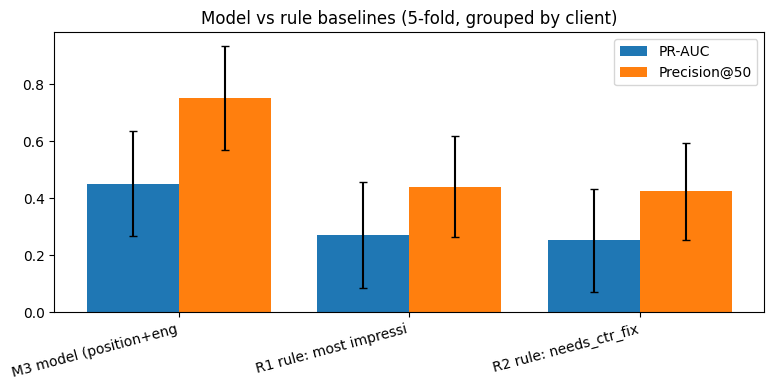

In [18]:
import matplotlib.pyplot as plt

def rank_metrics(y, s):
    top = np.argsort(-s)[:50]
    return average_precision_score(y, s), y[top].mean()

best = "3 + content + engagement"
rows2 = []
for fold, (tr, te) in enumerate(GroupKFold(n_splits=5).split(a, groups=a.client_hash_id)):
    trn, tst = a.iloc[tr], a.iloc[te]
    ytr, yte = make_labels(trn, tst)
    mtr, mte = ytr.notna(), yte.notna()
    t = tst.loc[mte]; y = yte[mte].astype(int).values
    scores = {
        "R1 rule: most impressions": t.impressions_30d.values.astype(float),
        "R2 rule: needs_ctr_fix flag": t.needs_ctr_fix.astype(int).values * 1e9 + t.impressions_30d.values,
    }
    m = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.08, max_iter=200,
                                       categorical_features="from_dtype", random_state=42)
    m.fit(trn.loc[mtr, sets[best]], ytr[mtr].astype(int))
    scores["M3 model (position+engagement+content)"] = m.predict_proba(t[sets[best]])[:, 1]
    for name, s in scores.items():
        pr, p50 = rank_metrics(y, s)
        rows2.append(dict(fold=fold, model=name, pr_auc=pr, prec_at_50=p50))

cmp = pd.DataFrame(rows2)
print(cmp.groupby("model")[["pr_auc", "prec_at_50"]].agg(["mean", "std"]).round(3).to_string())

piv = cmp.pivot(index="fold", columns="model", values="prec_at_50")
mc = "M3 model (position+engagement+content)"
for r in ["R1 rule: most impressions", "R2 rule: needs_ctr_fix flag"]:
    print(f"Folds where model beats {r} on precision@50:", int((piv[mc] > piv[r]).sum()), "of 5")

g = cmp.groupby("model")[["pr_auc", "prec_at_50"]].agg(["mean", "std"])
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(g))
ax.bar(x - 0.2, g[("pr_auc", "mean")], 0.4, yerr=g[("pr_auc", "std")], label="PR-AUC", capsize=3)
ax.bar(x + 0.2, g[("prec_at_50", "mean")], 0.4, yerr=g[("prec_at_50", "std")], label="Precision@50", capsize=3)
ax.set_xticks(x); ax.set_xticklabels([s[:22] for s in g.index], rotation=15, ha="right")
ax.set_title("Model vs rule baselines (5-fold, grouped by client)"); ax.legend()
plt.tight_layout(); plt.savefig("fig_baseline_vs_model.png", dpi=150); plt.show()

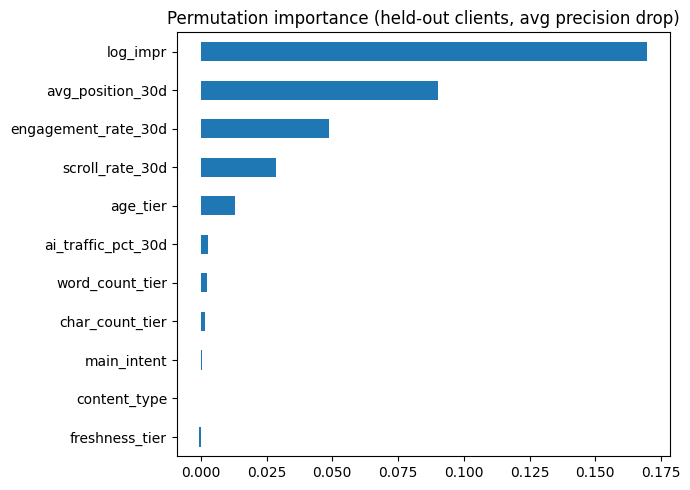

 rank    content_type  avg_position_30d  impressions_30d  ctr_30d  exp_ctr  score  missed_clicks                                     reason_codes                                 action
    1 keyword article               6.8           234138     0.02     0.57   0.77        1287.76 STRIKING_LOW_CTR|HIGH_VISIBILITY|ZERO_ENGAGEMENT Rewrite title/meta, check intent match
    2 keyword article               7.4           177331     0.02     0.35   0.92         585.19                 STRIKING_LOW_CTR|HIGH_VISIBILITY Rewrite title/meta, check intent match
    3 keyword article               6.4           521931     0.29     0.46   0.60         887.28                 STRIKING_LOW_CTR|HIGH_VISIBILITY Rewrite title/meta, check intent match
    4 keyword article               8.7           115400     0.01     0.48   0.96         542.38 STRIKING_LOW_CTR|HIGH_VISIBILITY|ZERO_ENGAGEMENT Rewrite title/meta, check intent match
    5 keyword article               7.1           119772     0.03     0.48 

In [19]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

feats = sets["3 + content + engagement"]
oof = pd.Series(np.nan, index=a.index)
exp_oof = pd.Series(np.nan, index=a.index)
lab_oof = pd.Series(np.nan, index=a.index)
imps = []

for fold, (tr, te) in enumerate(GroupKFold(n_splits=5).split(a, groups=a.client_hash_id)):
    trn, tst = a.iloc[tr], a.iloc[te]
    ytr, yte = make_labels(trn, tst)
    mtr, mte = ytr.notna(), yte.notna()
    m = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.08, max_iter=200,
                                       categorical_features="from_dtype", random_state=42)
    m.fit(trn.loc[mtr, feats], ytr[mtr].astype(int))
    t = tst.loc[mte]
    oof.loc[t.index] = m.predict_proba(t[feats])[:, 1]
    med = trn.groupby("pos_band").ctr_30d.median()
    exp_oof.loc[t.index] = t.pos_band.map(med).astype(float)
    lab_oof.loc[t.index] = yte[mte]
    r = permutation_importance(m, t[feats], yte[mte].astype(int),
                               scoring="average_precision", n_repeats=3, random_state=42)
    imps.append(pd.Series(r.importances_mean, index=feats))

imp = pd.concat(imps, axis=1).mean(axis=1).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax)
ax.set_title("Permutation importance (held-out clients, avg precision drop)")
plt.tight_layout(); plt.savefig("fig_feature_importance.png", dpi=150); plt.show()

sc = a.loc[oof.dropna().index].copy()
sc["score"] = oof
sc["exp_ctr"] = exp_oof
sc["missed_clicks"] = (sc.exp_ctr - sc.ctr_30d).clip(lower=0) / 100 * sc.impressions_30d
sc["priority"] = sc.score * sc.missed_clicks

def reasons(r):
    c = []
    if r.avg_position_30d <= 5: c.append("TOP5_LOW_CTR")
    elif r.avg_position_30d <= 10: c.append("STRIKING_LOW_CTR")
    else: c.append("LOWER_RANK_LOW_CTR")
    if r.impressions_30d >= sc.impressions_30d.quantile(0.75): c.append("HIGH_VISIBILITY")
    if r.engagement_rate_30d == 0: c.append("ZERO_ENGAGEMENT")
    return "|".join(c)

def action(r):
    if r.avg_position_30d <= 5: return "Review title/meta (snippet)"
    if r.avg_position_30d <= 10: return "Rewrite title/meta, check intent match"
    return "Content review, then monitor"

top = sc.sort_values("priority", ascending=False).head(20).copy()
top["reason_codes"] = top.apply(reasons, axis=1)
top["action"] = top.apply(action, axis=1)
top.insert(0, "rank", range(1, 21))
cols = ["rank", "content_type", "avg_position_30d", "impressions_30d", "ctr_30d",
        "exp_ctr", "score", "missed_clicks", "reason_codes", "action"]
out = top[cols].round(2)
print(out.to_string(index=False))

import os
os.makedirs("work/outputs", exist_ok=True)
out.to_csv("work/outputs/top20_recommendations.csv", index=False)
print("\nUnderperformer rate among top 20:", lab_oof.loc[top.index].mean())

In [20]:
print("Content type share in data:")
print(a.content_type.value_counts(normalize=True).round(3).head(5))

top_all = sc.sort_values("priority", ascending=False)
t20 = top_all.head(20)
print("\nClients represented in top 20:", t20.client_hash_id.nunique())
print("Pages per client in top 20:", sorted(t20.client_hash_id.value_counts().values, reverse=True))

div = top_all.groupby("client_hash_id").head(3).head(20)
print("\nDiversified list (max 3 per client): clients =", div.client_hash_id.nunique(),
      "| underperformer rate =", round(lab_oof.loc[div.index].mean(), 3))

sc["decile"] = pd.qcut(sc.score.rank(method="first"), 10, labels=False) + 1
print("\nUnderperformer rate by score decile (10 = highest score):")
print(sc.assign(lab=lab_oof).groupby("decile").lab.mean().round(3).to_string())

Content type share in data:
content_type
keyword article    0.996
feedly article     0.004
Name: proportion, dtype: float64

Clients represented in top 20: 4
Pages per client in top 20: [np.int64(13), np.int64(5), np.int64(1), np.int64(1)]

Diversified list (max 3 per client): clients = 10 | underperformer rate = 0.85

Underperformer rate by score decile (10 = highest score):
decile
1     0.046
2     0.075
3     0.114
4     0.156
5     0.201
6     0.248
7     0.302
8     0.372
9     0.494
10    0.682


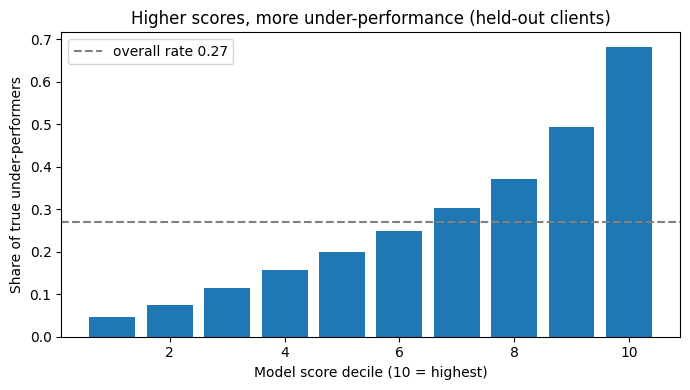

 rank  avg_position_30d  impressions_approx  ctr_30d  exp_ctr  score  est_missed_clicks                                       reason_codes                                 action
    1               6.8              234000     0.02     0.57   0.77               1290   STRIKING_LOW_CTR|HIGH_VISIBILITY|ZERO_ENGAGEMENT Rewrite title/meta, check intent match
    2               7.4              177000     0.02     0.35   0.92                590                   STRIKING_LOW_CTR|HIGH_VISIBILITY Rewrite title/meta, check intent match
    3               6.4              522000     0.29     0.46   0.60                890                   STRIKING_LOW_CTR|HIGH_VISIBILITY Rewrite title/meta, check intent match
    4               8.7              115000     0.01     0.48   0.96                540   STRIKING_LOW_CTR|HIGH_VISIBILITY|ZERO_ENGAGEMENT Rewrite title/meta, check intent match
    5               7.1              120000     0.03     0.48   0.93                540   STRIKING_LOW_CTR|HIG

In [21]:
import os, shutil
os.makedirs("docs/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

dec = sc.assign(lab=lab_oof).groupby("decile").lab.mean()
overall = lab_oof.mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dec.index, dec.values)
ax.axhline(overall, ls="--", color="gray", label=f"overall rate {overall:.2f}")
ax.set_xlabel("Model score decile (10 = highest)")
ax.set_ylabel("Share of true under-performers")
ax.set_title("Higher scores, more under-performance (held-out clients)")
ax.legend(); plt.tight_layout()
plt.savefig("fig_decile_lift.png", dpi=150); plt.show()

final = div.copy()
final["reason_codes"] = final.apply(reasons, axis=1)
final["action"] = final.apply(action, axis=1)
final.insert(0, "rank", range(1, len(final) + 1))
final["impressions_approx"] = (final.impressions_30d / 1000).round().astype(int) * 1000
final["est_missed_clicks"] = (final.missed_clicks / 10).round().astype(int) * 10
public = final[["rank", "avg_position_30d", "impressions_approx", "ctr_30d",
                "exp_ctr", "score", "est_missed_clicks", "reason_codes", "action"]].round(2)
public.to_csv("work/outputs/top20_public.csv", index=False)
print(public.to_string(index=False))

print("\nHEADLINE NUMBERS")
print("pages scored:", len(sc), "| clients:", sc.client_hash_id.nunique())
print("overall under-performer rate:", round(overall, 3))
print("top decile:", round(dec.iloc[-1], 3), "| bottom decile:", round(dec.iloc[0], 3))
print("top decile lift vs base:", round(dec.iloc[-1] / overall, 2))

for f in ["fig_baseline_vs_model.png", "fig_feature_importance.png", "fig_decile_lift.png"]:
    if os.path.exists(f):
        shutil.copy(f, "docs/figures/" + f)
print(os.listdir("docs/figures"))

Saved docs/index.html: 208 KB


#,Avg position,Impressions (≈),CTR %,Expected CTR %,Model score,Est. missed clicks (≈),Reason codes,Suggested action
1,6.8,234000,0.02,0.57,0.77,1290,STRIKING_LOW_CTR|HIGH_VISIBILITY|ZERO_ENGAGEMENT,"Rewrite title/meta, check intent match"
2,7.4,177000,0.02,0.35,0.92,590,STRIKING_LOW_CTR|HIGH_VISIBILITY,"Rewrite title/meta, check intent match"
3,6.4,522000,0.29,0.46,0.60,890,STRIKING_LOW_CTR|HIGH_VISIBILITY,"Rewrite title/meta, check intent match"
4,8.7,115000,0.01,0.48,0.96,540,STRIKING_LOW_CTR|HIGH_VISIBILITY|ZERO_ENGAGEMENT,"Rewrite title/meta, check intent match"
5,7.1,120000,0.03,0.48,0.93,540,STRIKING_LOW_CTR|HIGH_VISIBILITY|ZERO_ENGAGEMENT,"Rewrite title/meta, check intent match"
6,5.0,276000,0.16,0.61,0.32,1240,TOP5_LOW_CTR|HIGH_VISIBILITY,Review title/meta (snippet)
7,2.1,497000,0.55,0.77,0.32,1090,TOP5_LOW_CTR|HIGH_VISIBILITY,Review title/meta (snippet)
8,8.4,160000,0.02,0.33,0.71,500,STRIKING_LOW_CTR|HIGH_VISIBILITY,"Rewrite title/meta, check intent match"
9,5.3,145000,0.11,0.46,0.57,510,STRIKING_LOW_CTR|HIGH_VISIBILITY,"Rewrite title/meta, check intent match"
10,6.4,102000,0.09,0.46,0.75,380,STRIKING_LOW_CTR|HIGH_VISIBILITY,"Rewrite title/meta, check intent match"

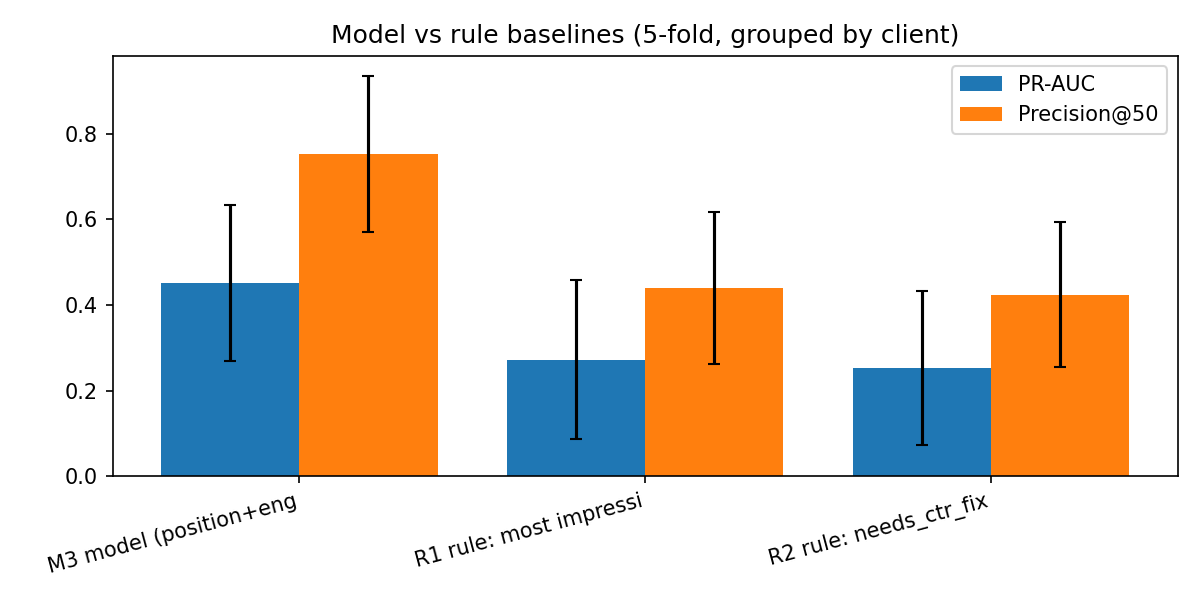
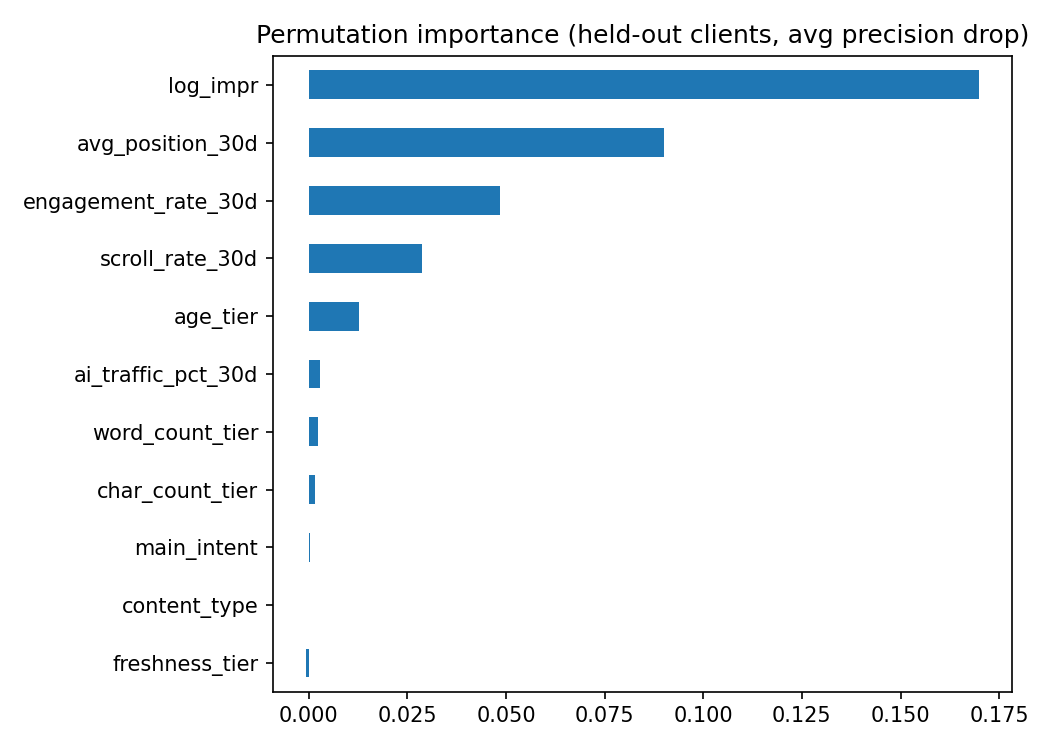
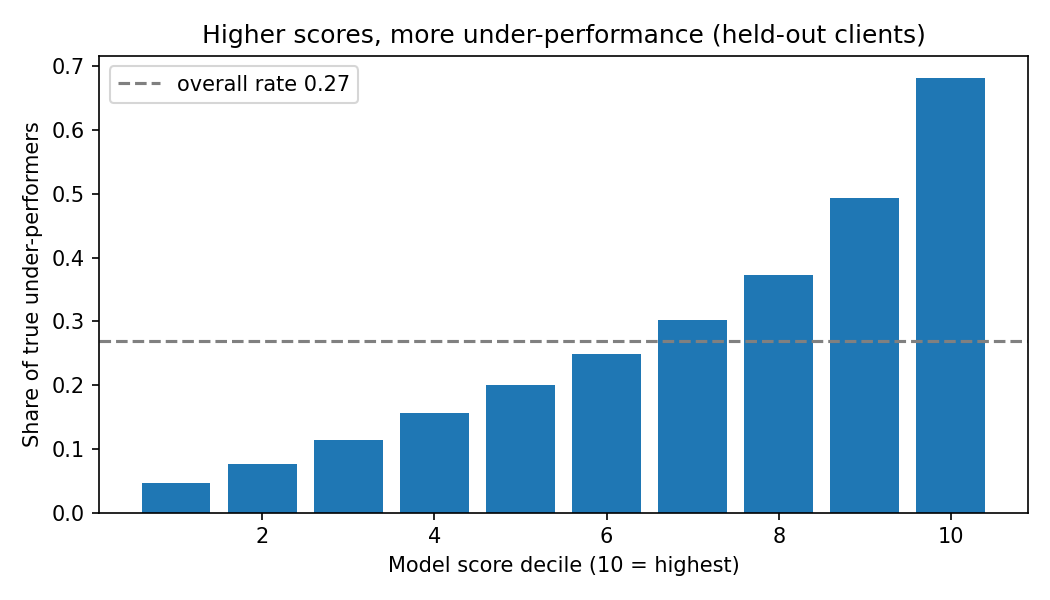

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import base64
from IPython.display import HTML, display

AUTHOR = "Your Name"   # <-- change this

def b64(p):
    return base64.b64encode(open(f"docs/figures/{p}.png", "rb").read()).decode()

tbl = public.copy()
tbl.columns = ["#", "Avg position", "Impressions (≈)", "CTR %", "Expected CTR %",
               "Model score", "Est. missed clicks (≈)", "Reason codes", "Suggested action"]
table_html = tbl.to_html(index=False, border=0)

PAGE = """<!doctype html><html lang="en"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Finding Pages That Under-Capture Clicks: A CTR Opportunity Model</title>
<style>
body{font-family:Georgia,serif;max-width:860px;margin:0 auto;padding:24px;line-height:1.6;color:#1a1a1a}
h1{font-size:1.9rem;line-height:1.25} h2{margin-top:2rem;border-bottom:1px solid #ddd;padding-bottom:4px}
.meta{color:#666;font-family:sans-serif;font-size:.9rem}
.abs{background:#f5f7fa;border-left:4px solid #2b6cb0;padding:12px 16px}
figure{margin:1.2rem 0} img{max-width:100%;height:auto} figcaption{font-size:.9rem;color:#555}
.wrap{overflow-x:auto} table{border-collapse:collapse;font-family:sans-serif;font-size:.8rem}
th,td{border-bottom:1px solid #e3e3e3;padding:4px 8px;text-align:left;white-space:nowrap}
code{background:#f0f0f0;padding:1px 4px;border-radius:3px}
</style></head><body>
<h1>Finding Pages That Under-Capture Clicks: A Client-Validated CTR Opportunity Model</h1>
<p class="meta">%%AUTHOR%% · FlyRank ML Internship Capstone · Lane 4: CTR / Engagement Opportunity Scoring</p>

<h2>Abstract</h2>
<p class="abs">Which already-visible pages receive fewer clicks than their ranking position would suggest, and can a model rank them better than simple rules? We use 26,375 pages from 38 clients in a pseudonymized search-engagement sample covering one 30-day window. A page is labelled a CTR under-performer when its click-through rate is below half the median for its position band, and a gradient-boosted model scores pages under 5-fold validation grouped by client. On held-out clients the model beat both rule baselines on precision@50 in all five folds (0.75 vs 0.44 and 0.42), and its top-scored decile held 68% under-performers against 27% overall. These findings are observational and directional: they prioritise pages for title and meta review, and they do not establish cause.</p>

<h2>1. Introduction / Problem statement</h2>
<p>Teams that manage many pages must decide where to spend limited review time. Pages that already rank and earn impressions but attract few clicks are cheap to improve, since a better title or description may help without new content. The decision this work supports is: <em>which pages should get a metadata or content review first?</em></p>

<h2>2. Data</h2>
<p>We used the pseudonymized <code>engagement_fix</code> example cut of the FlyRank ML Internship dataset: 33,202 page rows with 30-day impressions, clicks, CTR, average position, site-engagement measures and content tiers. We dropped 358 rows with no CTR or position, then kept pages with at least 100 impressions to avoid noisy CTRs, leaving 28,078 rows. After label construction, 26,375 pages from 38 clients were scored. Client IDs are hashed and no client names, domains, URLs or queries appear in this paper. Nearly all pages (99.6%) share one content type, so content type carries little signal in this sample.</p>

<h2>3. Methodology</h2>
<p><b>Label.</b> Pages were grouped into position bands (1-3, 3-5, 5-7, 7-10, 10-15, 15-20, 20-30, 30+). The expected CTR of a band is its median CTR, computed on training folds only. A page is an under-performer if its CTR is below 50% of that expected value.</p>
<p><b>Features.</b> Average position, log impressions, engagement rate, scroll rate, AI-traffic share, and content, age, freshness and length tiers. We excluded CTR, clicks and every rule flag that was derived from them, because they would leak the label. We also excluded sessions, users and pageviews from the headline model, since they track clicks closely (see Limitations).</p>
<p><b>Validation.</b> 5-fold <code>GroupKFold</code> by client, so no client appears in both training and test data. We used a histogram gradient-boosting classifier (depth 4, 200 iterations) and measured PR-AUC and precision@50 per fold.</p>
<p><b>Baselines.</b> Two rule rankings on the same folds: R1 ranks by impressions, and R2 ranks by the dataset's own <code>needs_ctr_fix</code> flag (ties broken by impressions).</p>

<h2>4. Results</h2>
<figure><img alt="Model vs baselines" src="data:image/png;base64,%%F1%%">
<figcaption>Figure 1. Model vs rule baselines on held-out clients (mean ± std over 5 folds).</figcaption></figure>
<p>The model reached a mean PR-AUC of 0.451 (R1: 0.272, R2: 0.252) and a mean precision@50 of 0.752 (R1: 0.440, R2: 0.424), and it won on precision@50 in 5 of 5 folds. The spread between folds is large (std about 0.18) because clients differ greatly in size and mix, so the ordering is consistent but the exact lift is uncertain. A position-and-impressions-only model scored PR-AUC 0.421, which means engagement features add a modest gain, while content features added none.</p>
<figure><img alt="Feature importance" src="data:image/png;base64,%%F2%%">
<figcaption>Figure 2. Permutation importance on held-out clients.</figcaption></figure>
<figure><img alt="Decile lift" src="data:image/png;base64,%%F3%%">
<figcaption>Figure 3. Share of true under-performers by model-score decile.</figcaption></figure>
<p>The share of true under-performers rises steadily from 4.6% in the lowest-scored decile to 68.2% in the highest, about 2.5 times the overall rate of 26.9%.</p>

<h2>5. Limitations &amp; honest framing</h2>
<ul>
<li><b>Observational, not causal.</b> The data cover a single 30-day window. We show association only and make no claim about how Google ranks pages or about the effect of any change.</li>
<li><b>Peer-relative label.</b> "Under-performer" means below half the typical CTR for similar positions in this sample. It is a prioritisation proxy and not an absolute standard.</li>
<li><b>Average position hides query mix.</b> Expected CTR did not fall smoothly with position, which suggests query and snippet effects that this data cannot separate.</li>
<li><b>Client imbalance.</b> The largest client holds 32% of scored pages and fold results vary widely, so the lift estimate is imprecise.</li>
<li><b>Proxy leakage.</b> Adding sessions, users and pageviews raised PR-AUC to 0.573, but these measures track clicks closely, so we report this as a sensitivity check and not as a result.</li>
<li><b>Narrow content mix and example cut.</b> Nearly all pages are one content type, and the data are a pseudonymized example cut and not the full warehouse.</li>
</ul>

<h2>6. Ranked recommendations &amp; action playbook</h2>
<p>The table lists the 20 highest-priority pages, capped at 3 per client for diversity. Priority is the model score multiplied by estimated missed clicks, where missed clicks = (expected CTR − actual CTR) × impressions for the window, an estimate for ordering only. Among these 20 pages, 85% were true under-performers on held-out clients. Impressions and missed clicks are rounded and no identifiers are shown.</p>
<div class="wrap">%%TABLE%%</div>
<p><b>Playbook.</b> <code>TOP5_LOW_CTR</code>: review the title and meta description (snippet). <code>STRIKING_LOW_CTR</code> (position 5-10): rewrite the title and meta, and check intent match. <code>LOWER_RANK_LOW_CTR</code>: run a content review, then monitor. <code>HIGH_VISIBILITY</code> marks the top quartile by impressions, so fixes there pay off most, and <code>ZERO_ENGAGEMENT</code> marks pages where engaged sessions are zero. Re-measure after any change, and treat the scores as a reviewing order, not a verdict.</p>

<h2>7. Reproducibility</h2>
<p>The full code is in the notebook <code>work/w08_capstone.ipynb</code> of the repository <a href="https://github.com/unatisaini/flyrank-internship-ml">github.com/unatisaini/flyrank-internship-ml</a>. Settings are <code>random_state=42</code>, <code>GroupKFold(5)</code> and a minimum of 100 impressions. The dataset needs gated access on Hugging Face and is not included here.</p>

<h2>Acknowledgments &amp; data credit</h2>
<p>Built on the <a href="https://flyrank.ai">FlyRank ML Internship dataset</a>.</p>
</body></html>"""

PAGE = (PAGE.replace("%%AUTHOR%%", AUTHOR)
            .replace("%%F1%%", b64("fig_baseline_vs_model"))
            .replace("%%F2%%", b64("fig_feature_importance"))
            .replace("%%F3%%", b64("fig_decile_lift"))
            .replace("%%TABLE%%", table_html))
open("docs/index.html", "w", encoding="utf-8").write(PAGE)

import shutil
from google.colab import files
shutil.make_archive("capstone_site", "zip", ".", "docs")
print("Saved docs/index.html:", round(len(PAGE) / 1024), "KB")
display(HTML(PAGE))
files.download("capstone_site.zip")